# Agentic RAG With LangGraph

In [50]:
from rich import print
import os
from dotenv import load_dotenv
load_dotenv()

True

In [26]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

In [27]:
# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
# llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
# embeddings = OpenAIEmbeddings()

In [28]:
from langchain_groq import ChatGroq
from langchain_community.embeddings import HuggingFaceEmbeddings


groq_api_key=os.getenv("GROQ_API_KEY")
llm=ChatGroq(groq_api_key=groq_api_key,model="meta-llama/llama-4-scout-17b-16e-instruct")
embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

/var/folders/26/r147q7cj1d53r_dsl52hh_w80000gn/T/ipykernel_9194/2310382177.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6781.68it/s]


In [29]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x121b007d0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x121b00b90>, model_name='meta-llama/llama-4-scout-17b-16e-instruct', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### State Definition

In [30]:
class AgentState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    needs_retrieval: bool

In [31]:
# Sample documents for demonstration
sample_texts = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.",
    "RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.",
    "Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.",
    "Agentic systems are AI systems that can take actions, make decisions, and interact with their environment autonomously. They often use planning and reasoning capabilities."
]

In [32]:
documents=[Document(page_content=text) for text in sample_texts]

In [33]:
vectorstore=FAISS.from_documents(documents=documents,embedding=embeddings)

In [34]:
retriever=vectorstore.as_retriever(k=3)

### Agents function

In [35]:
def decide_retrieval(state: AgentState) -> AgentState:
    """
    Decide if we need to retrieve documents based on the question
    """
    question = state["question"]
    
    # Simple heuristic: if question contains certain keywords, retrieve
    retrieval_keywords = ["what", "how", "explain", "describe", "tell me"]
    needs_retrieval = any(keyword in question.lower() for keyword in retrieval_keywords)
    
    return {**state, "needs_retrieval": needs_retrieval}

In [36]:
def retrieve_documents(state: AgentState) -> AgentState:
    """
    Retrieve relevant documents based on the question
    """
    question = state["question"]
    documents = retriever.invoke(question)
    
    return {**state, "documents": documents}

In [37]:
def generate_answer(state: AgentState) -> AgentState:
    """
    Generate an answer using the retrieved documents or direct response
    """
    question = state["question"]
    documents = state.get("documents", [])
    
    if documents:
        # RAG approach: use documents as context
        context = "\n\n".join([doc.page_content for doc in documents])
        prompt = f"""Based on the following context, answer the question:

Context:
{context}

Question: {question}

Answer:"""
    else:
        # Direct response without retrieval
        prompt = f"Answer the following question: {question}"
    
    response = llm.invoke(prompt)
    answer = response.content
    
    return {**state, "answer": answer}

### conditional Logic

In [38]:
def should_retrieve(state: AgentState) -> str:
    """
    Determine the next step based on retrieval decision
    """
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

### Build the Graph

In [39]:
workflow = StateGraph(AgentState)

In [40]:
workflow.add_node("decide",decide_retrieval)
workflow.add_node("retrieve",retrieve_documents)
workflow.add_node("generate",generate_answer)

In [41]:
workflow.set_entry_point("decide")

In [42]:
workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve":"retrieve",
        "generate":"generate",
    }
)

In [45]:
workflow.add_edge("retrieve","generate")
workflow.add_edge("generate",END)

In [46]:
app = workflow.compile()

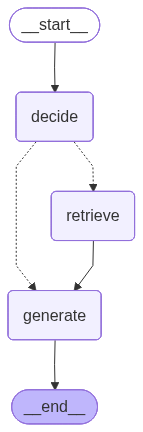

In [47]:
app

### Test the Agentic System

In [48]:
def ask_question(question: str):
    """
    Helper function to ask a question and get an answer
    """
    initial_state = {
        "question": question,
        "documents": [],
        "answer": "",
        "needs_retrieval": False
    }
    
    result = app.invoke(initial_state)
    return result

In [51]:
# Test with a question that should trigger retrieval
question1 = "What is LangGraph?"
result1 = ask_question(question1)
print(result1)

{
    'question': 'What is LangGraph?',
    'documents': [
        Document(
            id='570f3234-058f-48d9-8ac8-e4522c212387',
            metadata={},
            page_content='LangGraph is a library for building stateful, multi-actor applications with LLMs. It 
extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic 
manner.'
        ),
        Document(
            id='b698c9a6-0bc4-4b22-8d93-80a1c48ce543',
            metadata={},
            page_content='RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval 
with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate
responses.'
        ),
        Document(
            id='e0fd6a50-bfa5-492b-84bb-c6a3a18c48f8',
            metadata={},
            page_content='Vector databases store high-dimensional vectors and enable efficient similarity search. 
They are commonly used in RAG systems to find relevant documents based on semantic similarity.'
        ),
        Document(
            id='e56c57ff-af32-4250-8971-6a713b61c101',
            metadata={},
            page_content='Agentic systems are AI systems that can take actions, make decisions, and interact with 
their environment autonomously. They often use planning and reasoning capabilities.'
        )
    ],
    'answer': 'LangGraph is a library for building stateful, multi-actor applications with LLMs (Large Language 
Models). It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation 
in a cyclic manner, enabling the development of more complex and dynamic applications.',
    'needs_retrieval': True
}